## Introduction

Demonstration to generate the plots from a trained nerual network


In [177]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd

import sys
sys.path.append('../')
from utility import *
from selex import *

import joblib

In [16]:
args = create_args()

In [ ]:
torch.enable_grad()
random.seed(args.seed)
torch.manual_seed(args.seed)


# Load the object from the .pkl file
pca = joblib.load(f"{args.save_dir}/pca_info_edit.pkl")

device = torch.device('cuda:' + str(args.gpu)
                        if torch.cuda.is_available() else 'cpu')
# load dataset
integral_time = args.timepoints

integral_time = args.timepoints
data_train,count_train,max=loaddata_selex(args,device)

# model
func = UOT(in_out_dim=30, hidden_dim=args.hidden_dim,n_hiddens=args.n_hiddens,activation=args.activation).to(device)#data_train[0].shape[1]

# load trained networks
if args.save_dir is not None:
    if not os.path.exists(args.save_dir):
        os.makedirs(args.save_dir)
    ckpt_path = os.path.join(args.save_dir, f'ckpt_itr{args.last}.pth')
    if os.path.exists(ckpt_path):
        checkpoint = torch.load(ckpt_path,map_location=torch.device('cpu'))
        func.load_state_dict(checkpoint['func_state_dict'])
        print('Loaded ckpt from {}'.format(ckpt_path))

Loaded ckpt from ./ckpt_itr5000.pth


## Violin Plot of the Growth
Generate a violin plot representing density of the growth throughout rounds 

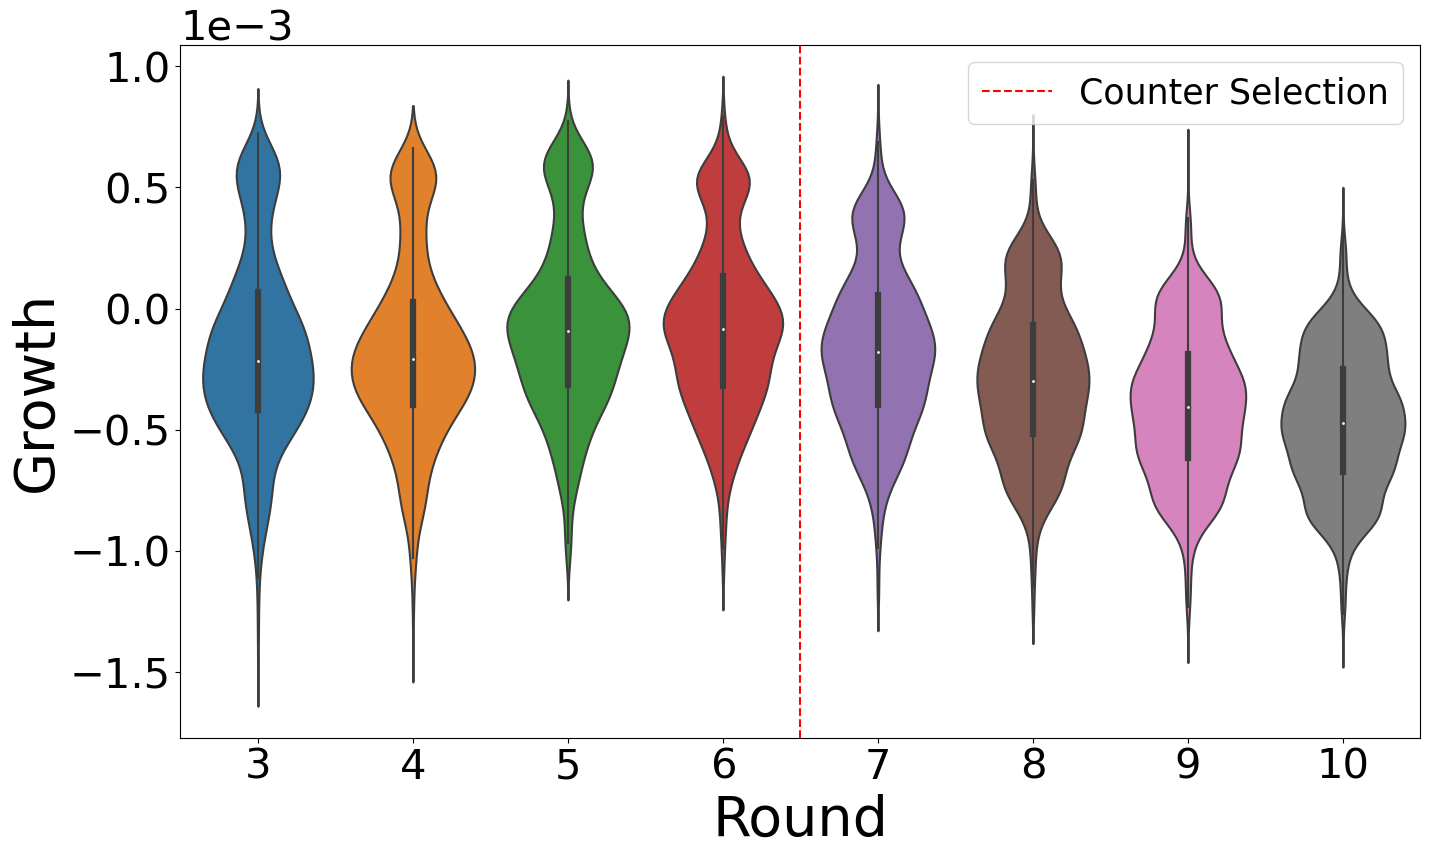

In [ ]:
g_xt=plot_growth_v(func,data_train,count_train,integral_time,device)

## LOSS
Plotting the componets of the loss, sum, transport cost, local reconstruction and global reconstruction

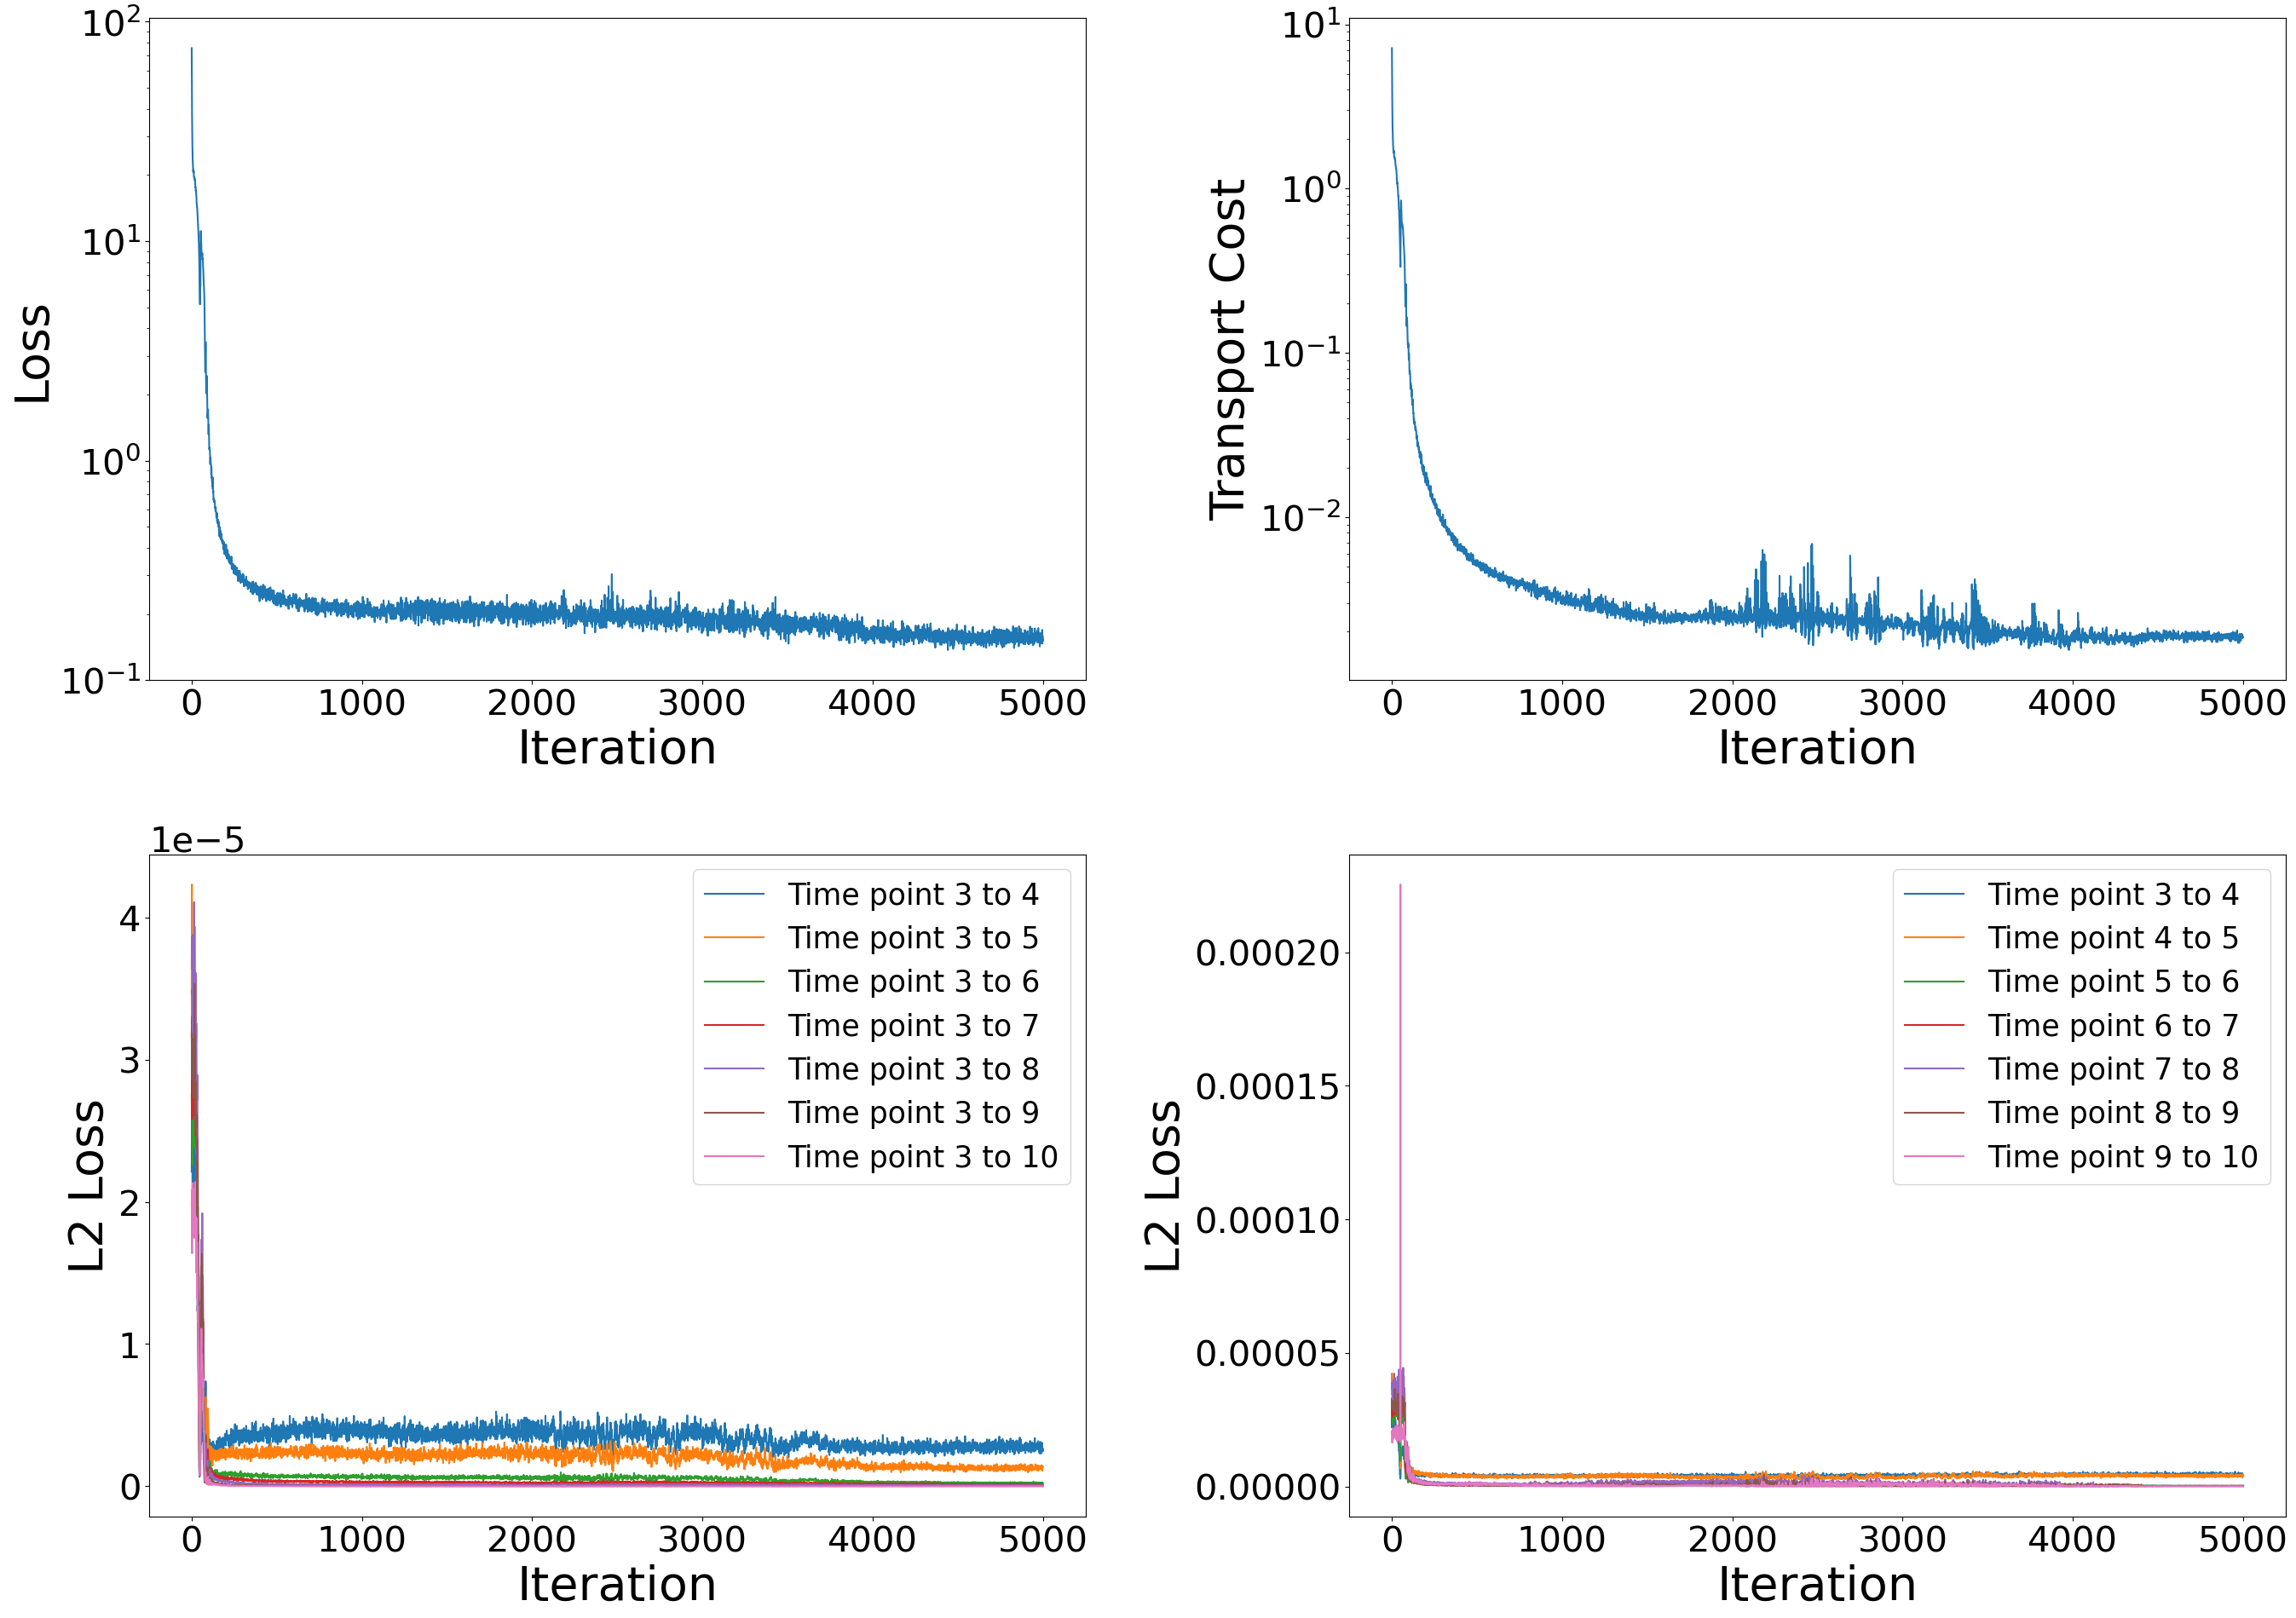

In [ ]:
#plotting the loss and the three componets 
plot_loss(checkpoint,integral_time)

In [154]:
integral_time=[3,4,5,6,7,8,9,10]
data_train=[]
counts_train=[]
for t in integral_time:
    with np.load(f'./grid_edit/grid{t}.npz') as data:
        grid=data['grid'] 
        count=data['count']
    counts_train.append(torch.from_numpy(count).type(torch.float32).to(device))
    data_train.append(grid)
grid_t=np.vstack(data_train)
max=np.sqrt(np.max(grid_t**2))
new=[]
for i in range(len(integral_time)):
    n=data_train[i]/max
    new.append(torch.from_numpy(n).type(torch.float32).to(device))
data_train=new

## Velocity and Trajectory
Plotting the average predicted pairwise distance and the average predicted speed over time

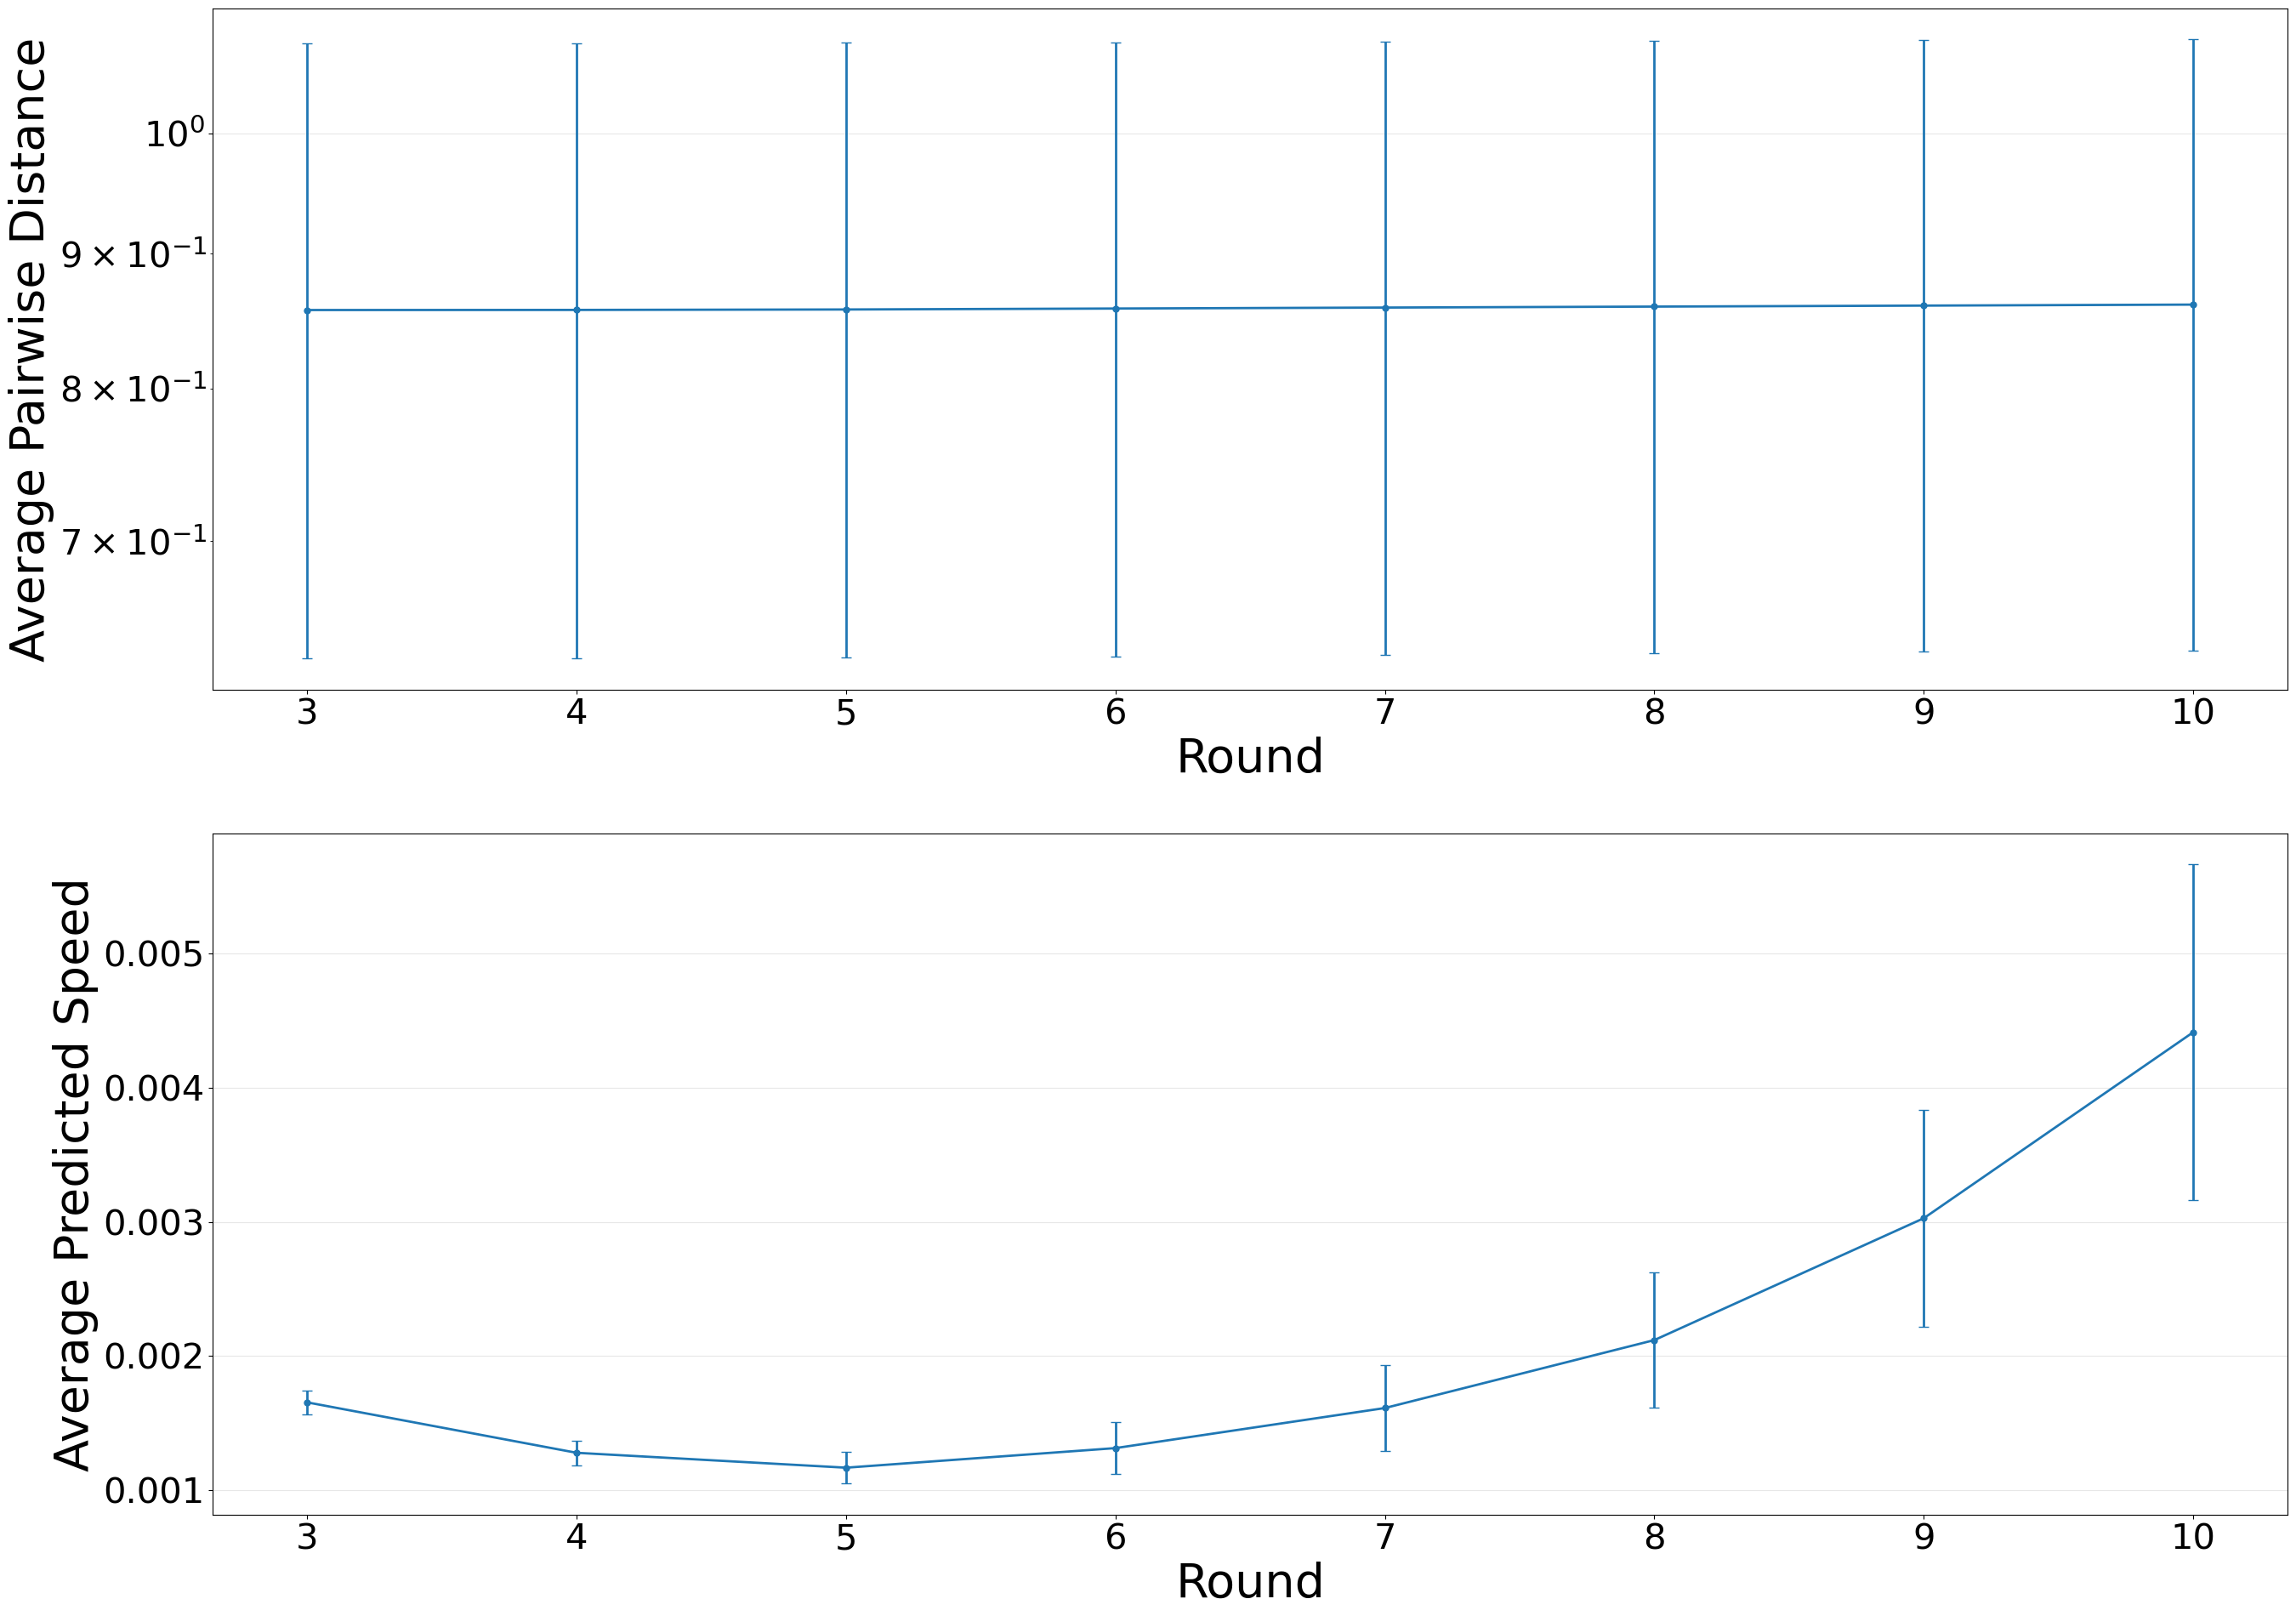

In [173]:
samp,vel,time=plot_3d_vel_change(func,data_train,counts_train,train_time,integral_time,args,device)
plot_change(samp,vel,integral_time)

### Generate the plot of regulatory matrix
Plot avergae regulatory matrices of cells (z_t) at time (time_pt).

Here we use first time points as an examples

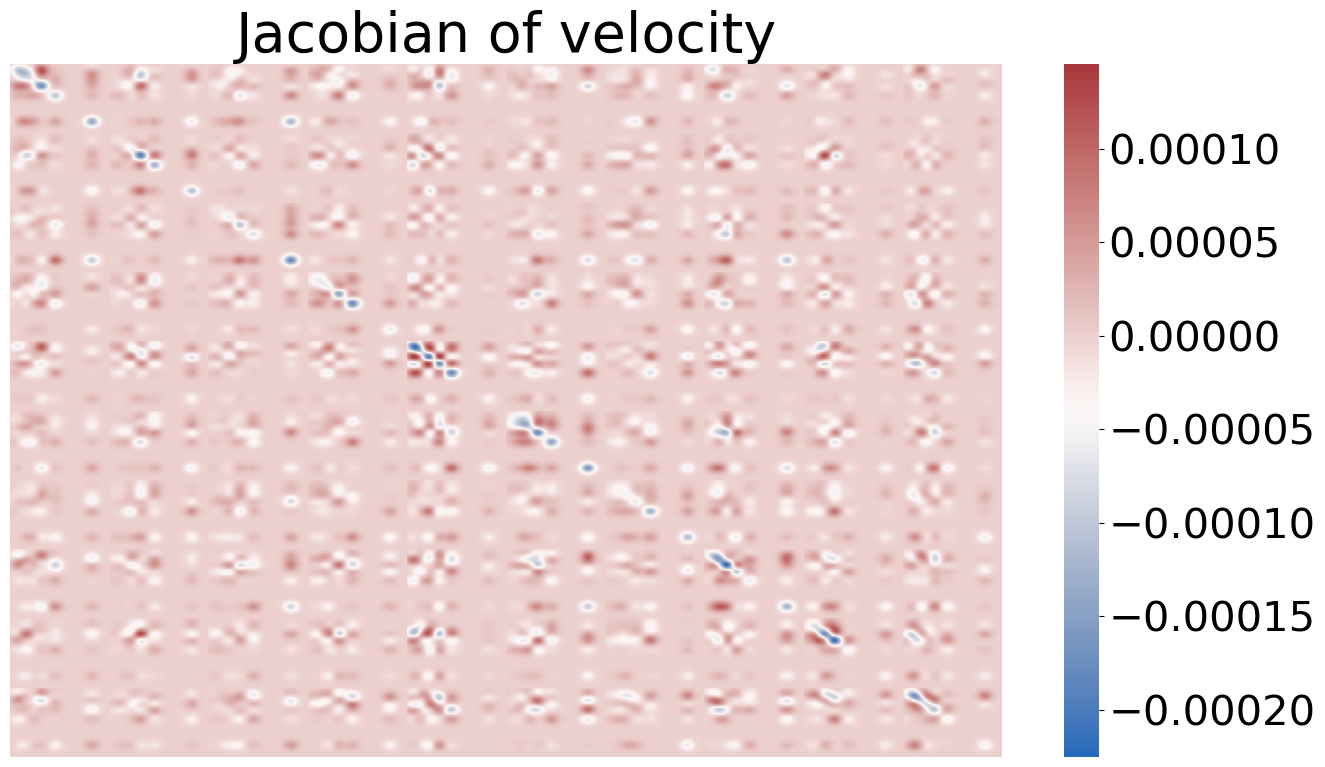

In [190]:
time_pt = len(integral_time)-1
import joblib
# Load the object from the .pkl file
z_t = data_train[time_pt]
plot_jac_v(pca,func,z_t,time_pt,'Average_jac_d0.pdf',args,device)

### Generate the plot of gradient of growth
Plot avergae gradients of g of cells (z_t) at time (time_pt).

Here we use first time points as an examples

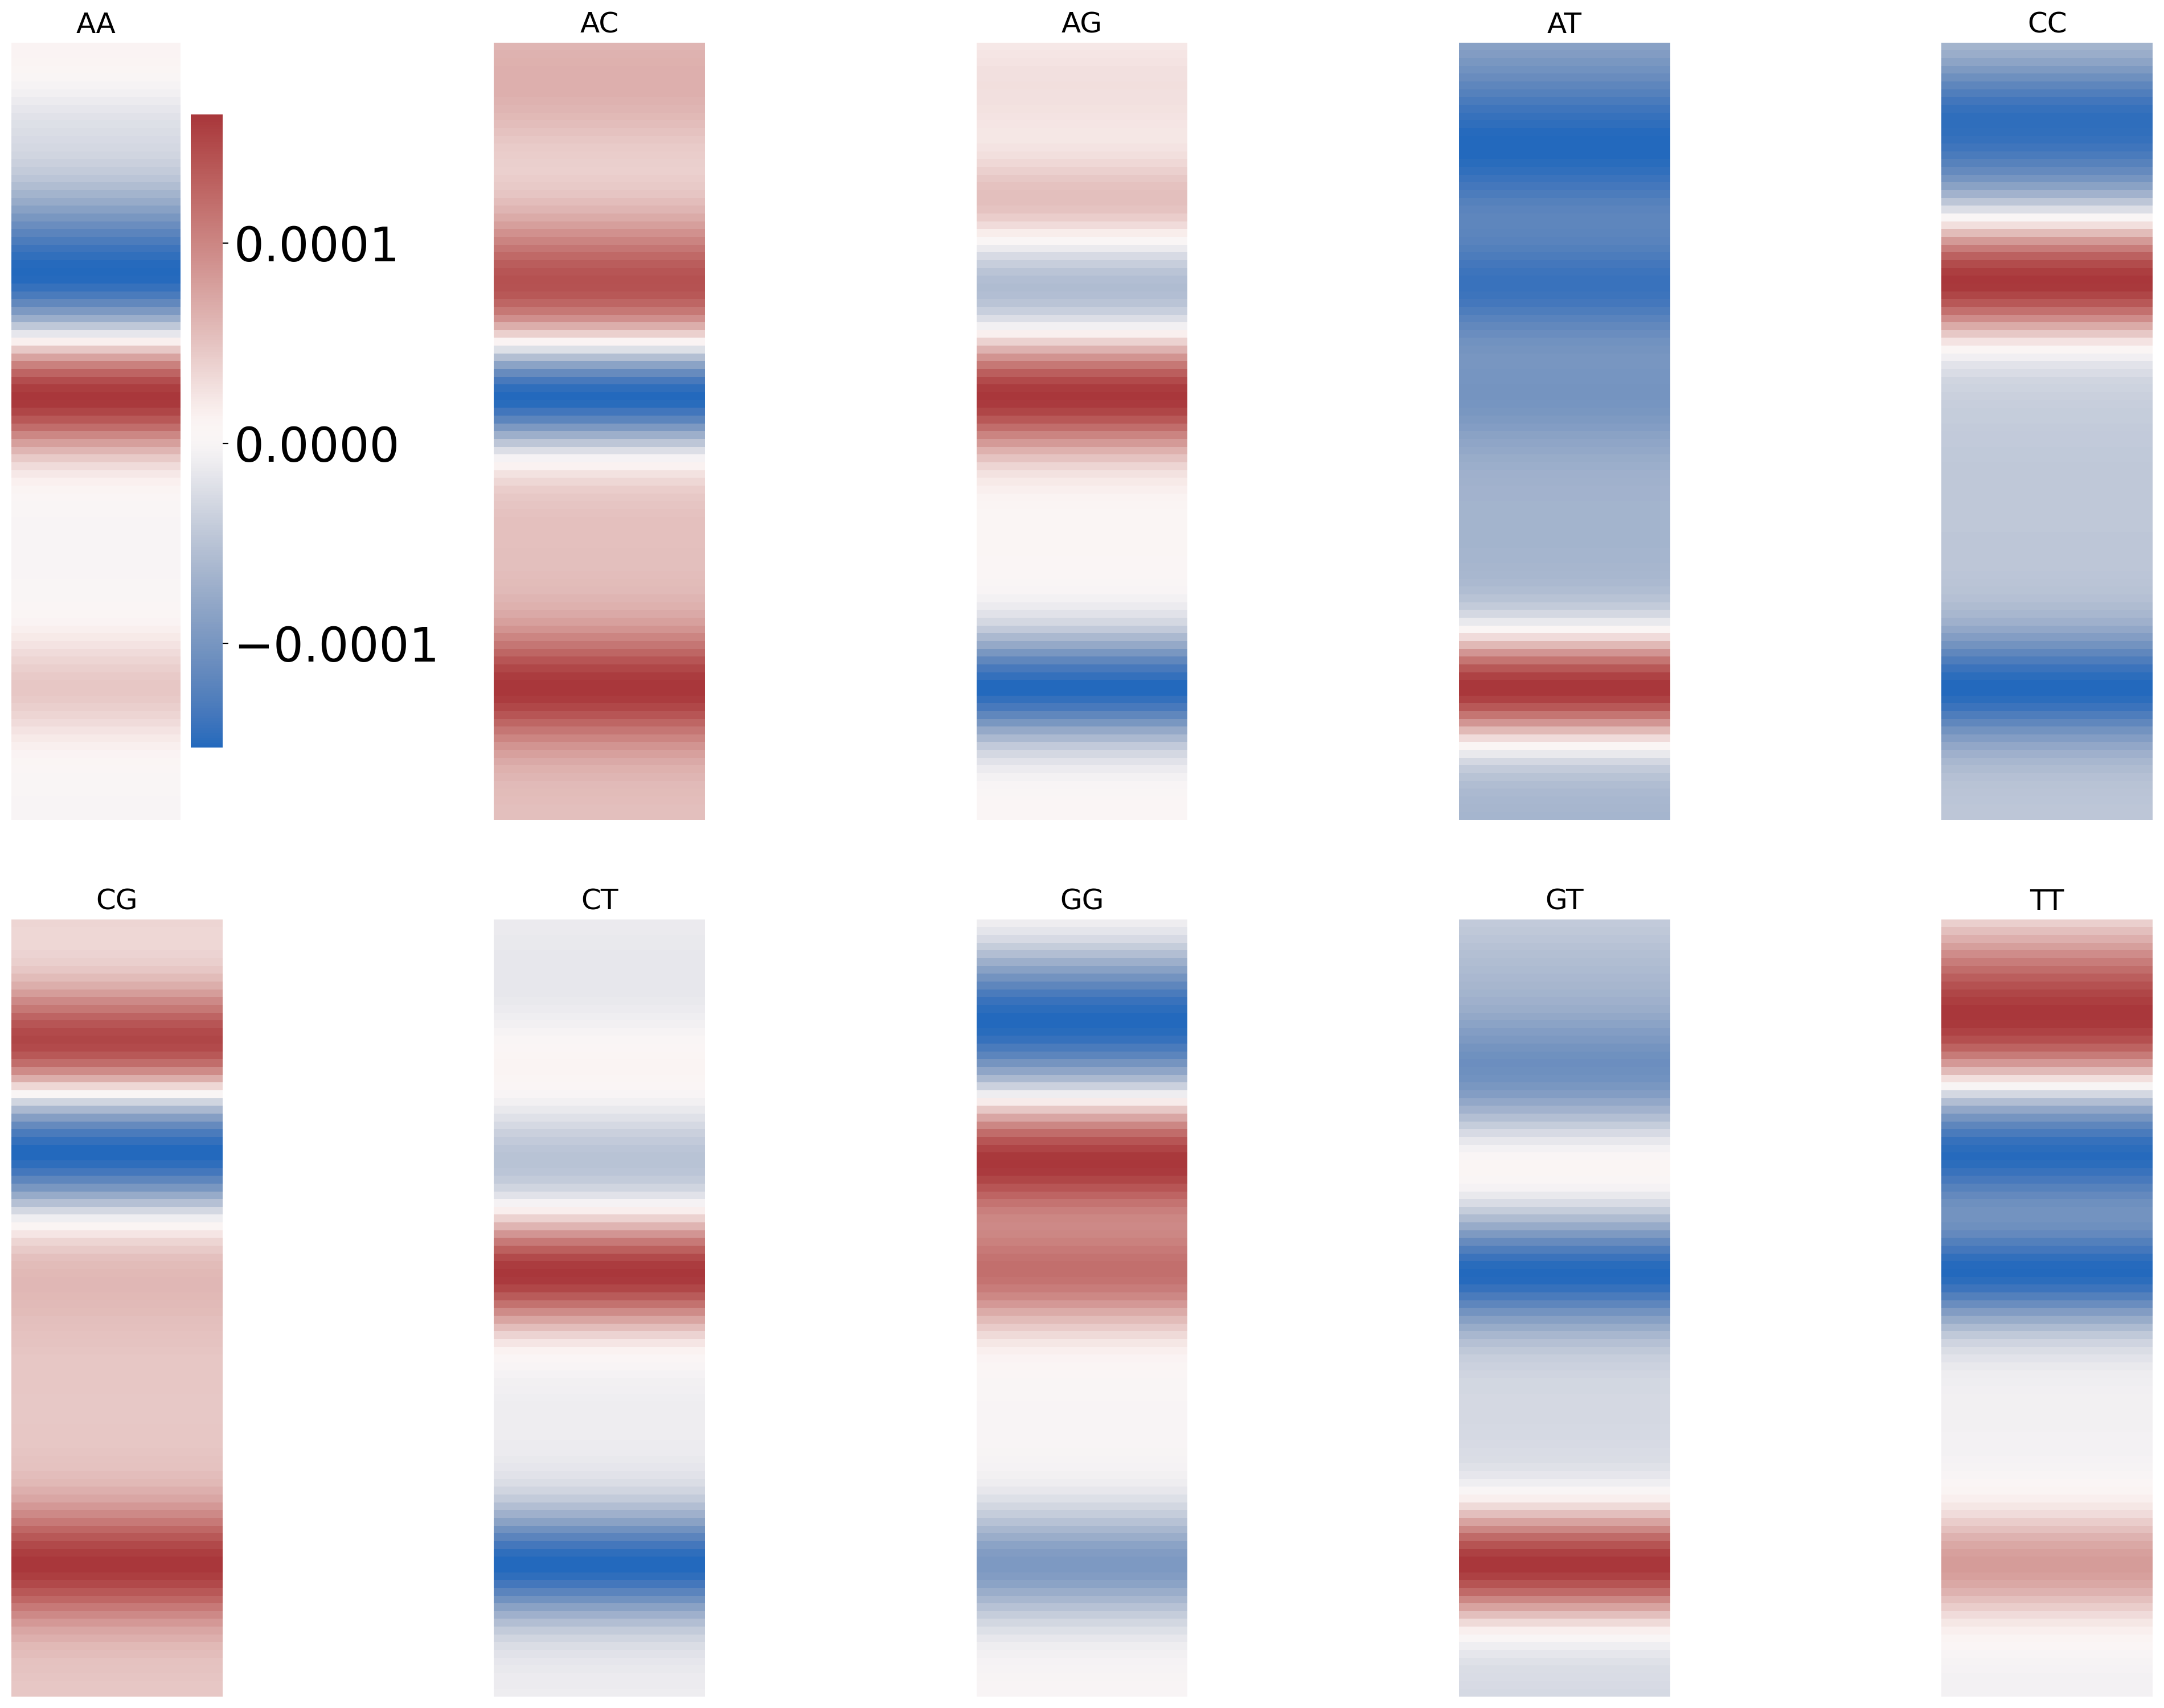

In [194]:
time_pt = len(integral_time)-1
z_t = data_train[time_pt]
gg=plot_grad_g(pca,func,z_t,time_pt,'Average_grad_d0.pdf',args,device)